# Explore Optimizers

In this section, the model will be trained using the following optimizers:

1. Adam
2. AdamW
3. SGD
4. SGD with Momentum
5. SGD with Nesterov
6. RMSprop

The $R^2$ score will also be computed for each optimizer.

## Libraries

In [2]:
# Prevent OpenMP runtime conflict between libraries like PyTorch, TensorFlow, and NumPy on Windows
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

import sys
import os
sys.path.append(os.path.abspath(".."))

import importlib
import src.training_utils as tu
importlib.reload(tu)

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

## Load Data
Load the data prepared in `01_data_preparation.ipynb`.

In [3]:
data = torch.load('../saved_values/data.pt', weights_only=False)

x_train = data["x_train"]
y_train = data["y_train"]

x_valid = data["x_valid"]
y_valid = data["y_valid"]

x_test = data["x_test"]
y_test = data["y_test"]

## Convert to Tensors

Since the data is currently in NumPy array format, I will convert it to PyTorch tensors.

In [4]:
x_train = torch.FloatTensor(x_train)
y_train = torch.FloatTensor(y_train)

x_valid = torch.FloatTensor(x_valid)
y_valid = torch.FloatTensor(y_valid)

x_test = torch.FloatTensor(x_test)
y_test = torch.FloatTensor(y_test)

## Data Loader

Create data loaders for the training, validation, and test sets.

In [5]:
train_dataset = TensorDataset(x_train, y_train)
train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)

valid_dataset = TensorDataset(x_valid, y_valid)
valid_loader = DataLoader(valid_dataset, batch_size=256)

test_dataset = TensorDataset(x_test, y_test)
test_loader = DataLoader(test_dataset, batch_size=256)

## Define the Model Architecture

In [23]:
model = tu.Model(in_features=20, h1=64, h2=32, out_features=1)

## Loss Function

Given that the MAE loss function demonstrated the best performance in `02_loss_functions.ipynb`, it was adopted as the loss function for the optimizer experiment.

In [24]:
loss_fn = nn.L1Loss()

## Optimziers

### 1. Adam

Adam was introduced by **Diederik P. Kingma** and **Jimmy Lei Ba** in 2015 at ICLR. [Paper link](https://arxiv.org/pdf/1412.6980).

The Adam optimizer combines the ideas of Momentum and RMSprop by maintaining exponentially decaying averages of both gradients and squared gradients.

$$
m_t = \beta_1 m_{t-1} + (1 - \beta_1) g_t
$$

$$
v_t = \beta_2 v_{t-1} + (1 - \beta_2) g_t^2
$$

$$
\hat{m}_t = \frac{m_t}{1 - \beta_1^t}, \quad \hat{v}_t = \frac{v_t}{1 - \beta_2^t}
$$

$$
\theta_t = \theta_{t-1} - \alpha \frac{\hat{m}_t}{\sqrt{\hat{v}_t} + \epsilon}
$$

In [13]:
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

In [20]:
trainer = tu.Trainer(model=model, optimizer=optimizer, loss_fn=loss_fn)

history_adam = trainer.fit(train_loader, valid_loader, epochs=300, name="Adam")

Output()

          Epoch 1/300           
┏━━━━━━━━┳━━━━━━━━┳━━━━━━━━━━━━┓
┃ Metric ┃  Train ┃ Validation ┃
┡━━━━━━━━╇━━━━━━━━╇━━━━━━━━━━━━┩
│ Loss   │ 0.4758 │     0.3856 │
│ R²     │ 0.5519 │     0.6901 │
└────────┴────────┴────────────┘

          Epoch 10/300          
┏━━━━━━━━┳━━━━━━━━┳━━━━━━━━━━━━┓
┃ Metric ┃  Train ┃ Validation ┃
┡━━━━━━━━╇━━━━━━━━╇━━━━━━━━━━━━┩
│ Loss   │ 0.3225 │     0.3442 │
│ R²     │ 0.7644 │     0.7485 │
└────────┴────────┴────────────┘

          Epoch 20/300          
┏━━━━━━━━┳━━━━━━━━┳━━━━━━━━━━━━┓
┃ Metric ┃  Train ┃ Validation ┃
┡━━━━━━━━╇━━━━━━━━╇━━━━━━━━━━━━┩
│ Loss   │ 0.3061 │     0.3271 │
│ R²     │ 0.7805 │     0.7627 │
└────────┴────────┴────────────┘

          Epoch 30/300          
┏━━━━━━━━┳━━━━━━━━┳━━━━━━━━━━━━┓
┃ Metric ┃  Train ┃ Validation ┃
┡━━━━━━━━╇━━━━━━━━╇━━━━━━━━━━━━┩
│ Loss   │ 0.2937 │     0.3195 │
│ R²     │ 0.7942 │     0.7655 │
└────────┴────────┴────────────┘

...

         Epoch 260/300          
┏━━━━━━━━┳━━━━━━━━┳━━━━━━━━━━━━┓
┃ Metric ┃  Train ┃ Validation ┃
┡━━━━━━━━╇━━━━━━━━╇━━━━━━━━━━━━┩
│ Loss   │ 0.2473 │     0.3015 │
│ R²     │ 0.8435 │     0.7850 │
└────────┴────────┴────────────┘

         Epoch 270/300          
┏━━━━━━━━┳━━━━━━━━┳━━━━━━━━━━━━┓
┃ Metric ┃  Train ┃ Validation ┃
┡━━━━━━━━╇━━━━━━━━╇━━━━━━━━━━━━┩
│ Loss   │ 0.2455 │     0.2981 │
│ R²     │ 0.8455 │     0.7869 │
└────────┴────────┴────────────┘

         Epoch 280/300          
┏━━━━━━━━┳━━━━━━━━┳━━━━━━━━━━━━┓
┃ Metric ┃  Train ┃ Validation ┃
┡━━━━━━━━╇━━━━━━━━╇━━━━━━━━━━━━┩
│ Loss   │ 0.2442 │     0.3025 │
│ R²     │ 0.8473 │     0.7827 │
└────────┴────────┴────────────┘

         Epoch 290/300          
┏━━━━━━━━┳━━━━━━━━┳━━━━━━━━━━━━┓
┃ Metric ┃  Train ┃ Validation ┃
┡━━━━━━━━╇━━━━━━━━╇━━━━━━━━━━━━┩
│ Loss   │ 0.2449 │     0.3126 │
│ R²     │ 0.8466 │     0.7796 │
└────────┴────────┴────────────┘

         Epoch 300/300          
┏━━━━━━━━┳━━━━━━━━┳━━━━━━━━━━━━┓
┃ Metric ┃  Train ┃ Validation ┃
┡━━━━━━━━╇━━━━━━━━╇━━━━━━━━━━━━┩
│ Loss   │ 0.2424 │     0.3022 │
│ R²     │ 0.8481 │     0.7830 │
└────────┴────────┴────────────┘

#### Plot the Results

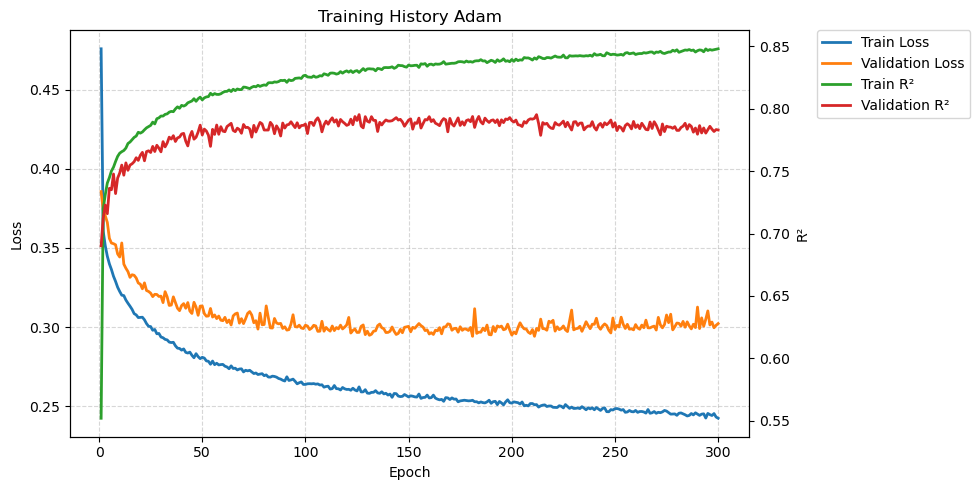

In [21]:
tu.plot_training_history(history_adam, "Adam")

### 2. AdamW

AdamW was introduced by **Ilya Loshchilov** and **Frank Hutter** in 2019. It addresses a key issue in Adam regarding L2 regularization by decoupling weight decay from the gradient-based parameter update. This leads to better generalization and more effective regularization. [Paper link](https://arxiv.org/pdf/1711.05101).

The AdamW optimizer maintains exponentially decaying averages of both gradients and squared gradients, similar to Adam, but applies weight decay as a separate step.

$$
m_t = \beta_1 m_{t-1} + (1 - \beta_1) g_t
$$

$$
v_t = \beta_2 v_{t-1} + (1 - \beta_2) g_t^2
$$

$$
\hat{m}_t = \frac{m_t}{1 - \beta_1^t}, \quad \hat{v}_t = \frac{v_t}{1 - \beta_2^t}
$$

$$
\theta_t = \theta_{t-1} - \alpha \left( \frac{\hat{m}_t}{\sqrt{\hat{v}_t} + \epsilon} + \lambda \theta_{t-1} \right)
$$

Unlike Adam with L2 regularization, AdamW applies weight decay independently of the adaptive gradient update, resulting in improved optimization performance and better model generalization.

In [24]:
optimizer = torch.optim.AdamW(model.parameters(), lr=0.001, weight_decay=0.0001)

In [25]:
trainer = tu.Trainer(model=model, optimizer=optimizer, loss_fn=loss_fn)

history_adamw = trainer.fit(train_loader, valid_loader, epochs=300, name="AdamW")

Output()

          Epoch 1/300           
┏━━━━━━━━┳━━━━━━━━┳━━━━━━━━━━━━┓
┃ Metric ┃  Train ┃ Validation ┃
┡━━━━━━━━╇━━━━━━━━╇━━━━━━━━━━━━┩
│ Loss   │ 0.4783 │     0.3944 │
│ R²     │ 0.5321 │     0.6872 │
└────────┴────────┴────────────┘

          Epoch 10/300          
┏━━━━━━━━┳━━━━━━━━┳━━━━━━━━━━━━┓
┃ Metric ┃  Train ┃ Validation ┃
┡━━━━━━━━╇━━━━━━━━╇━━━━━━━━━━━━┩
│ Loss   │ 0.3236 │     0.3411 │
│ R²     │ 0.7633 │     0.7522 │
└────────┴────────┴────────────┘

          Epoch 20/300          
┏━━━━━━━━┳━━━━━━━━┳━━━━━━━━━━━━┓
┃ Metric ┃  Train ┃ Validation ┃
┡━━━━━━━━╇━━━━━━━━╇━━━━━━━━━━━━┩
│ Loss   │ 0.3036 │     0.3257 │
│ R²     │ 0.7834 │     0.7628 │
└────────┴────────┴────────────┘

          Epoch 30/300          
┏━━━━━━━━┳━━━━━━━━┳━━━━━━━━━━━━┓
┃ Metric ┃  Train ┃ Validation ┃
┡━━━━━━━━╇━━━━━━━━╇━━━━━━━━━━━━┩
│ Loss   │ 0.2952 │     0.3194 │
│ R²     │ 0.7932 │     0.7709 │
└────────┴────────┴────────────┘

...

         Epoch 260/300          
┏━━━━━━━━┳━━━━━━━━┳━━━━━━━━━━━━┓
┃ Metric ┃  Train ┃ Validation ┃
┡━━━━━━━━╇━━━━━━━━╇━━━━━━━━━━━━┩
│ Loss   │ 0.2514 │     0.2951 │
│ R²     │ 0.8382 │     0.7982 │
└────────┴────────┴────────────┘

         Epoch 270/300          
┏━━━━━━━━┳━━━━━━━━┳━━━━━━━━━━━━┓
┃ Metric ┃  Train ┃ Validation ┃
┡━━━━━━━━╇━━━━━━━━╇━━━━━━━━━━━━┩
│ Loss   │ 0.2509 │     0.2944 │
│ R²     │ 0.8389 │     0.7986 │
└────────┴────────┴────────────┘

         Epoch 280/300          
┏━━━━━━━━┳━━━━━━━━┳━━━━━━━━━━━━┓
┃ Metric ┃  Train ┃ Validation ┃
┡━━━━━━━━╇━━━━━━━━╇━━━━━━━━━━━━┩
│ Loss   │ 0.2504 │     0.2945 │
│ R²     │ 0.8392 │     0.7973 │
└────────┴────────┴────────────┘

         Epoch 290/300          
┏━━━━━━━━┳━━━━━━━━┳━━━━━━━━━━━━┓
┃ Metric ┃  Train ┃ Validation ┃
┡━━━━━━━━╇━━━━━━━━╇━━━━━━━━━━━━┩
│ Loss   │ 0.2505 │     0.2931 │
│ R²     │ 0.8394 │     0.7968 │
└────────┴────────┴────────────┘

         Epoch 300/300          
┏━━━━━━━━┳━━━━━━━━┳━━━━━━━━━━━━┓
┃ Metric ┃  Train ┃ Validation ┃
┡━━━━━━━━╇━━━━━━━━╇━━━━━━━━━━━━┩
│ Loss   │ 0.2483 │     0.2930 │
│ R²     │ 0.8409 │     0.7951 │
└────────┴────────┴────────────┘

#### Plot the Results

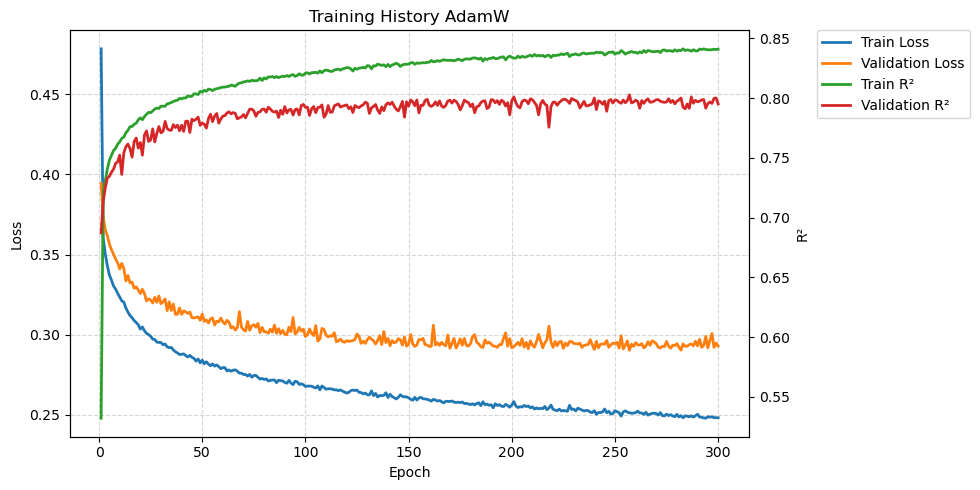

In [26]:
tu.plot_training_history(history_adamw, "AdamW")

### 3. SGD (Stochastic Gradient Descent)
$$ \theta_{t+1}=\theta_t-
\eta
\nabla_{\theta}
\mathcal{L}_i(\theta_t)
$$

In [9]:
optimizer = torch.optim.SGD(model.parameters(), lr=0.001)

In [10]:
trainer = tu.Trainer(model=model, optimizer=optimizer, loss_fn=loss_fn)

history_sgd = trainer.fit(train_loader, valid_loader, epochs=300, name="SGD1e-3")

Output()

          Epoch 1/300           
┏━━━━━━━━┳━━━━━━━━┳━━━━━━━━━━━━┓
┃ Metric ┃  Train ┃ Validation ┃
┡━━━━━━━━╇━━━━━━━━╇━━━━━━━━━━━━┩
│ Loss   │ 0.7768 │     0.7631 │
│ R²     │ 0.0390 │     0.0422 │
└────────┴────────┴────────────┘

          Epoch 10/300          
┏━━━━━━━━┳━━━━━━━━┳━━━━━━━━━━━━┓
┃ Metric ┃  Train ┃ Validation ┃
┡━━━━━━━━╇━━━━━━━━╇━━━━━━━━━━━━┩
│ Loss   │ 0.7068 │     0.6982 │
│ R²     │ 0.0866 │     0.0930 │
└────────┴────────┴────────────┘

          Epoch 20/300          
┏━━━━━━━━┳━━━━━━━━┳━━━━━━━━━━━━┓
┃ Metric ┃  Train ┃ Validation ┃
┡━━━━━━━━╇━━━━━━━━╇━━━━━━━━━━━━┩
│ Loss   │ 0.6087 │     0.6015 │
│ R²     │ 0.2698 │     0.2816 │
└────────┴────────┴────────────┘

          Epoch 30/300          
┏━━━━━━━━┳━━━━━━━━┳━━━━━━━━━━━━┓
┃ Metric ┃  Train ┃ Validation ┃
┡━━━━━━━━╇━━━━━━━━╇━━━━━━━━━━━━┩
│ Loss   │ 0.4857 │     0.4824 │
│ R²     │ 0.5181 │     0.5172 │
└────────┴────────┴────────────┘

...

         Epoch 260/300          
┏━━━━━━━━┳━━━━━━━━┳━━━━━━━━━━━━┓
┃ Metric ┃  Train ┃ Validation ┃
┡━━━━━━━━╇━━━━━━━━╇━━━━━━━━━━━━┩
│ Loss   │ 0.3491 │     0.3736 │
│ R²     │ 0.7301 │     0.7089 │
└────────┴────────┴────────────┘

         Epoch 270/300          
┏━━━━━━━━┳━━━━━━━━┳━━━━━━━━━━━━┓
┃ Metric ┃  Train ┃ Validation ┃
┡━━━━━━━━╇━━━━━━━━╇━━━━━━━━━━━━┩
│ Loss   │ 0.3482 │     0.3727 │
│ R²     │ 0.7314 │     0.7103 │
└────────┴────────┴────────────┘

         Epoch 280/300          
┏━━━━━━━━┳━━━━━━━━┳━━━━━━━━━━━━┓
┃ Metric ┃  Train ┃ Validation ┃
┡━━━━━━━━╇━━━━━━━━╇━━━━━━━━━━━━┩
│ Loss   │ 0.3472 │     0.3716 │
│ R²     │ 0.7327 │     0.7113 │
└────────┴────────┴────────────┘

         Epoch 290/300          
┏━━━━━━━━┳━━━━━━━━┳━━━━━━━━━━━━┓
┃ Metric ┃  Train ┃ Validation ┃
┡━━━━━━━━╇━━━━━━━━╇━━━━━━━━━━━━┩
│ Loss   │ 0.3463 │     0.3708 │
│ R²     │ 0.7334 │     0.7130 │
└────────┴────────┴────────────┘

         Epoch 300/300          
┏━━━━━━━━┳━━━━━━━━┳━━━━━━━━━━━━┓
┃ Metric ┃  Train ┃ Validation ┃
┡━━━━━━━━╇━━━━━━━━╇━━━━━━━━━━━━┩
│ Loss   │ 0.3454 │     0.3699 │
│ R²     │ 0.7349 │     0.7141 │
└────────┴────────┴────────────┘

#### Plot the Results

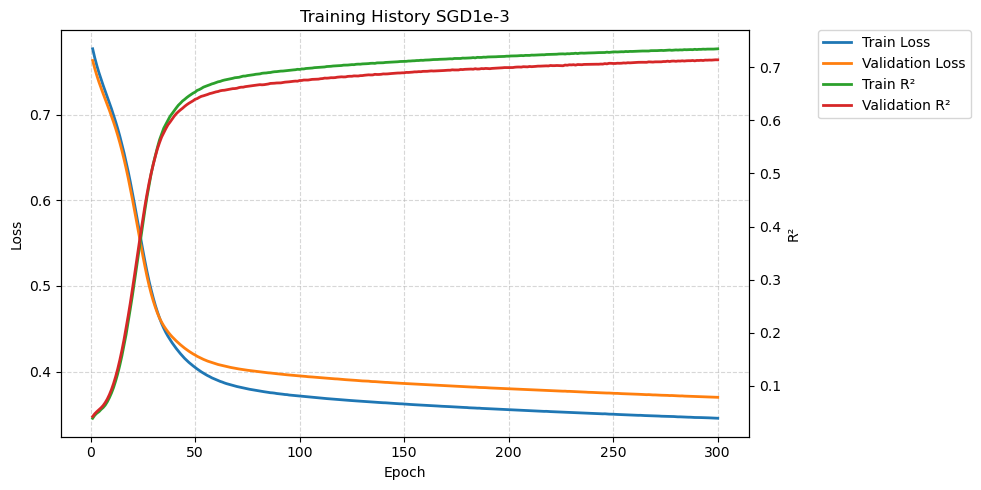

In [11]:
tu.plot_training_history(history_sgd, "SGD1e-3")

## 4. SGD with Momentum

$$
\begin{aligned}
m_t &= \beta m_{t-1} + (1 - \beta) \nabla_{\theta}\mathcal{L}(\theta_{t-1}) \\
\theta_t &= \theta_{t-1} - \eta m_t
\end{aligned}
$$

In [25]:
optimizer = torch.optim.SGD(model.parameters(), lr=0.001, momentum=0.9)

In [26]:
trainer = tu.Trainer(model=model, optimizer=optimizer, loss_fn=loss_fn)

history_sgd_m = trainer.fit(train_loader, valid_loader, epochs=300, name="SGD_M")

Output()

           Epoch 1/300           
┏━━━━━━━━┳━━━━━━━━━┳━━━━━━━━━━━━┓
┃ Metric ┃   Train ┃ Validation ┃
┡━━━━━━━━╇━━━━━━━━━╇━━━━━━━━━━━━┩
│ Loss   │  0.7613 │     0.7063 │
│ R²     │ -0.0199 │     0.0399 │
└────────┴─────────┴────────────┘

          Epoch 10/300          
┏━━━━━━━━┳━━━━━━━━┳━━━━━━━━━━━━┓
┃ Metric ┃  Train ┃ Validation ┃
┡━━━━━━━━╇━━━━━━━━╇━━━━━━━━━━━━┩
│ Loss   │ 0.3728 │     0.3915 │
│ R²     │ 0.6990 │     0.6852 │
└────────┴────────┴────────────┘

          Epoch 20/300          
┏━━━━━━━━┳━━━━━━━━┳━━━━━━━━━━━━┓
┃ Metric ┃  Train ┃ Validation ┃
┡━━━━━━━━╇━━━━━━━━╇━━━━━━━━━━━━┩
│ Loss   │ 0.3554 │     0.3744 │
│ R²     │ 0.7232 │     0.7084 │
└────────┴────────┴────────────┘

          Epoch 30/300          
┏━━━━━━━━┳━━━━━━━━┳━━━━━━━━━━━━┓
┃ Metric ┃  Train ┃ Validation ┃
┡━━━━━━━━╇━━━━━━━━╇━━━━━━━━━━━━┩
│ Loss   │ 0.3456 │     0.3648 │
│ R²     │ 0.7358 │     0.7249 │
└────────┴────────┴────────────┘

...

         Epoch 260/300          
┏━━━━━━━━┳━━━━━━━━┳━━━━━━━━━━━━┓
┃ Metric ┃  Train ┃ Validation ┃
┡━━━━━━━━╇━━━━━━━━╇━━━━━━━━━━━━┩
│ Loss   │ 0.2868 │     0.3173 │
│ R²     │ 0.7990 │     0.7729 │
└────────┴────────┴────────────┘

         Epoch 270/300          
┏━━━━━━━━┳━━━━━━━━┳━━━━━━━━━━━━┓
┃ Metric ┃  Train ┃ Validation ┃
┡━━━━━━━━╇━━━━━━━━╇━━━━━━━━━━━━┩
│ Loss   │ 0.2858 │     0.3156 │
│ R²     │ 0.8000 │     0.7722 │
└────────┴────────┴────────────┘

         Epoch 280/300          
┏━━━━━━━━┳━━━━━━━━┳━━━━━━━━━━━━┓
┃ Metric ┃  Train ┃ Validation ┃
┡━━━━━━━━╇━━━━━━━━╇━━━━━━━━━━━━┩
│ Loss   │ 0.2848 │     0.3149 │
│ R²     │ 0.8009 │     0.7756 │
└────────┴────────┴────────────┘

         Epoch 290/300          
┏━━━━━━━━┳━━━━━━━━┳━━━━━━━━━━━━┓
┃ Metric ┃  Train ┃ Validation ┃
┡━━━━━━━━╇━━━━━━━━╇━━━━━━━━━━━━┩
│ Loss   │ 0.2837 │     0.3165 │
│ R²     │ 0.8020 │     0.7743 │
└────────┴────────┴────────────┘

         Epoch 300/300          
┏━━━━━━━━┳━━━━━━━━┳━━━━━━━━━━━━┓
┃ Metric ┃  Train ┃ Validation ┃
┡━━━━━━━━╇━━━━━━━━╇━━━━━━━━━━━━┩
│ Loss   │ 0.2827 │     0.3154 │
│ R²     │ 0.8031 │     0.7767 │
└────────┴────────┴────────────┘

#### Plot the results

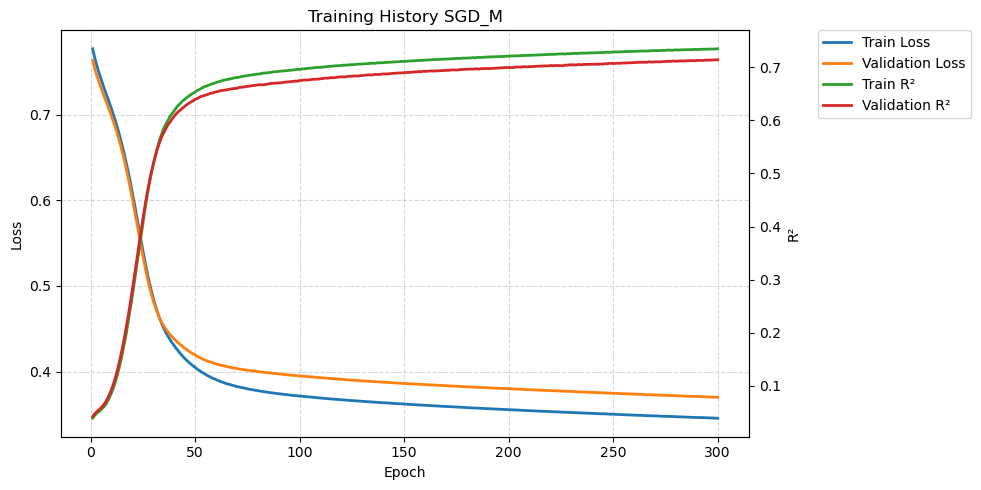

In [ ]:
tu.plot_training_history(history_sgd_m, "SGD_M")